### VLM finetuning example

After granting this model, you can download the model using hugginface

In [ ]:
!pip install -q -U transformers datasets accelerate
!pip install -q -U peft bitsandbytes
!pip install gradio
# !pip install ipywidgets
# flaviagiammarino/vqa-rad

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [2]:
from datasets import load_dataset
ds = load_dataset('henrik-dra/energy-meter') # https://huggingface.co/datasets/henrik-dra/energy-meter
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 138
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 30
    })
})


Label: 8952.3


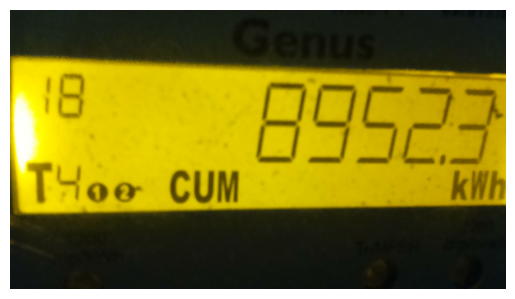

In [7]:
import matplotlib.pyplot as plt

ds_train=ds['train']
ds_test=ds['test']

print(f'Label: {ds_test[7]["label"]}')
plt.imshow(ds_test[7]['image'])
plt.axis('off')
plt.show()

In [ ]:
from transformers import PaliGemmaProcessor
model_id = "google/paligemma-3b-pt-224"  # https://huggingface.co/google/paligemma-3b-pt-224
processor = PaliGemmaProcessor.from_pretrained(model_id)

In [ ]:
device = "cuda"

In [6]:
import torch
import numpy as np
import builtins
builtins.np = np

def collate_fn(examples):
    texts = ["<image> extract meter value from this image" for example in examples]
    labels= [example['label'] for example in examples]
    images = [example["image"].convert("RGB") for example in examples]
    tokens = processor(text=texts, images=images, suffix=labels,
                    return_tensors="pt", padding="longest")

    tokens = tokens.to(torch.bfloat16).to(device)
    return tokens

In [7]:
from transformers import PaliGemmaForConditionalGeneration
from transformers import BitsAndBytesConfig
from peft import get_peft_model, LoraConfig
import torch

bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_type=torch.bfloat16
)

lora_config = LoraConfig(
    r=8,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)
model = PaliGemmaForConditionalGeneration.from_pretrained(model_id, quantization_config=bnb_config, device_map={"":0})
for name, param in model.named_parameters():
    if "vision" in name or "projector" in name:
        param.requires_grad = False
        # print(f"Parameter '{name}' is frozen.")

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "c:\ProgramData\miniconda3\envs\venv_lmm\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\ProgramData\miniconda3\envs\venv_lmm\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\ProgramData\miniconda3\envs\venv_lmm\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 6: invalid start byte


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

trainable params: 11,298,816 || all params: 2,934,765,296 || trainable%: 0.3850


In [8]:
from transformers import TrainingArguments
args=TrainingArguments(
            num_train_epochs=2,
            remove_unused_columns=False,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=2,
            warmup_steps=2,
            learning_rate=2e-5,
            weight_decay=1e-6,
            adam_beta2=0.999,
            logging_steps=100,
            optim="adamw_torch",
            save_strategy="steps",
            save_steps=138,
            push_to_hub=False,
            save_total_limit=1,
            output_dir="paligemma_meter",
            bf16=True,
            # report_to=["tensorboard"],
            dataloader_pin_memory=False
        )


In [ ]:
from transformers import Trainer

trainer = Trainer(
        model=model,
        train_dataset=ds_train ,
        eval_dataset=ds_test,
        data_collator=collate_fn,
        args=args
        )

trainer.train()

In [ ]:
# trainer.push_to_hub("vlm_ocr_paligemma")
# model = PaliGemmaForConditionalGeneration.from_pretrained("vlm_ocr_paligemma")

In [ ]:
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration
import torch
from PIL import Image
import gradio as gr
from huggingface_hub import login
from transformers import BitsAndBytesConfig
import io

def generate_response(question, image):
    # Convert the uploaded image to a PIL image
    raw_image = Image.fromarray(image).convert("RGB")

    # Prepare inputs
    inputs = processor(text=question, images=raw_image, return_tensors="pt")
    device = model.device
    for k, v in inputs.items():
        inputs[k] = v.to(device)
    # Generate response
    output = model.generate(**inputs, max_new_tokens=20)

    # Decode and return response
    response = processor.decode(output[0], skip_special_tokens=True)[len(question):]
    return response

# Gradio Interface
def chat_interface(question, image):
    if question is None or image is None:
        return "Please provide both an image and a question."
    response = generate_response(question, image)
    return response

with gr.Blocks() as iface:
    gr.Markdown("# finetuned PaliGemma")
    gr.Markdown("Upload an image and ask a question (ex. what is exact meter value from this image) about it.")

    with gr.Row():
        with gr.Column():
            question = gr.Textbox(label="Question", placeholder="Enter your question here...", lines=1)
            image = gr.Image(label="Upload Image", type="numpy")
            predict_button = gr.Button("Predict")

        response = gr.Textbox(label="Response")

    predict_button.click(
        fn=chat_interface,
        inputs=[question, image],
        outputs=response
    )

iface.launch(share=True,debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://302a92d962187a7691.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.
Y